In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv(r"C:\Users\srija\OneDrive\Desktop\machine learning\DEEP LEARNING\datasets\powerplant_data.csv")

In [12]:
df.head(5)
# AT - temperature value
# V - vaccum
# AO - Pressure
# RH - Humidity

# PE - Prouduce Energy

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [13]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [14]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [15]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [16]:
# Training in Neural network
# 1. Load the Dataset
# 2. Data convert to Tensors
# 3. TensorDataset and DataLoader
# 4. Define ANN model  
# 5. Train the model (save the model too)
# 6. Evaluation

In [18]:
# Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1 ,1)
# y_train.values because, its a pandas core series not a numpy array
# .view(-1, 1) because its only has one column.

In [34]:
# Data Loader - to define how the data will be loaded for training
# - creates batches for us
# - shuffles (optional )
# Tensor Dataset class - it recives raw data, and transfer it to Data Loader(DL cant access raw data from memory).
# - access data
# - can access one sample / one row(features, target)

from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [35]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

## Deep Learning

In [48]:
# Defined Artificial Neural Network Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st Hidden Layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            # 2nd Hidden Layer
            nn.Linear(6, 6),
            nn.ReLU(),

            #output layer
            nn.Linear(6, 1),
        )

    def forward(self, x):
        return self.model(x)


# No need to write backward propagation.

In [49]:
import torch.optim as optim

model = ANN()

# Loss, optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [60]:
# Train the ANN

train_loss = []
val_losses = []

epochs = 100
for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # trainig loss for 1 epoch

    for xb, yb, in train_loader:
        #xb - features of 1 batch
        #yb - labels of 1 batch

        optimizer.zero_grad() # Fresh gradients repeatedly

        # 1. forward Propagation.
        outputs = model(xb) # Predicted outputs for this batch

        # 2. compute loss.
        loss = criterion(outputs, yb)

        # 3. backward propagation
        loss.backward()

        # 4. update parameters
        optimizer.step()

        # running loss - for all the batches.
        running_loss += loss.item() # convert tensor to float values with .items()
    
    epoch_train_loss  = running_loss / len(train_loader)
    train_loss.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # so that gradient is not computed
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")


Epoch 1/100 | Train Loss: 20.9231 | Val Loss: 20.6654
Epoch 2/100 | Train Loss: 20.9607 | Val Loss: 19.0226
Epoch 3/100 | Train Loss: 20.9085 | Val Loss: 19.2989
Epoch 4/100 | Train Loss: 21.0846 | Val Loss: 19.2495
Epoch 5/100 | Train Loss: 20.9552 | Val Loss: 19.1831
Epoch 6/100 | Train Loss: 20.9794 | Val Loss: 19.1187
Epoch 7/100 | Train Loss: 21.0381 | Val Loss: 19.0305
Epoch 8/100 | Train Loss: 20.8051 | Val Loss: 18.8139
Epoch 9/100 | Train Loss: 20.7446 | Val Loss: 19.6042
Epoch 10/100 | Train Loss: 20.8932 | Val Loss: 19.0604
Epoch 11/100 | Train Loss: 21.0319 | Val Loss: 19.4899
Epoch 12/100 | Train Loss: 20.8891 | Val Loss: 19.2941
Epoch 13/100 | Train Loss: 20.9995 | Val Loss: 19.2275
Epoch 14/100 | Train Loss: 20.8729 | Val Loss: 19.0860
Epoch 15/100 | Train Loss: 20.8565 | Val Loss: 19.0442
Epoch 16/100 | Train Loss: 20.9947 | Val Loss: 19.2170
Epoch 17/100 | Train Loss: 20.9684 | Val Loss: 18.8778
Epoch 18/100 | Train Loss: 20.9993 | Val Loss: 19.4282
Epoch 19/100 | Trai

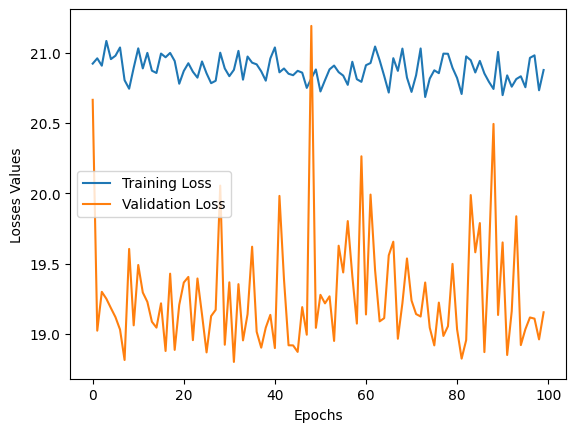

: 

In [ ]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training loss": train_loss,
    "Validation loss": val_losses 
})

plt.plot(loss_df["Training loss"], label = "Training Loss")
plt.plot(loss_df["Validation loss"], label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Losses Values")
plt.legend()